## Import Thư Viện

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, json
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import wandb
import copy
import warnings
warnings.filterwarnings('ignore')
import os

wandb.login()

WANDB_PROJECT = "house-prices-regression"

## Load Data

In [161]:
train_path = "train.csv"
test_path = "test.csv"
TARGET = "SalePrice"

In [162]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [163]:
print(f"Train dataset : {train.shape[0]} dòng, {train.shape[1]} cột")
print(f"Test dataset  : {test.shape[0]} dòng, {test.shape[1]} cột")
print(f"Target column : {TARGET}")

Train dataset : 1460 dòng, 81 cột
Test dataset  : 1459 dòng, 80 cột
Target column : SalePrice


In [164]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [165]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Data Analysis

### Thông tin về tập dữ liệu

In [166]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [167]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

### Phân loại biến: numeric vs categorical

In [168]:
train["MSSubClass"] = train["MSSubClass"].astype(str)
test["MSSubClass"] = test["MSSubClass"].astype(str)

In [169]:
feature_cols = [col for col in train.columns if col not in ["Id", TARGET]]

numeric_cols = train[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Số biến numerical   : {len(numeric_cols)}")
print(f"Số biến categorical : {len(categorical_cols)}")

print("\nNumerical features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)

Số biến numerical   : 35
Số biến categorical : 44

Numerical features:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features:
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Kit

### Thống kê mô tả

In [170]:
print("\n--- Thống kê Numerical Features ---")
numeric_summary = train[numeric_cols].describe().T
numeric_summary["Missing"] = train[numeric_cols].isnull().sum()
numeric_summary["Skewness"] = train[numeric_cols].skew()
display(numeric_summary)


--- Thống kê Numerical Features ---


,count,mean,std,min,25%,50%,75%,max,Missing,Skewness
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0,259,2.163569
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0,0,12.207688
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0,0,0.216944
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0,0,0.693067
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0,0,-0.613461
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0,0,-0.503562
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0,8,2.669084
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0,0,1.685503
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0,0,4.255261
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0,0,0.920268


In [171]:
DISCRETE_UNIQUE_THRESHOLD = 25
discrete_cols = [col for col in numeric_cols if train[col].nunique() <= DISCRETE_UNIQUE_THRESHOLD]

print(f"\n--- Tần suất: Biến Numeric Discrete (<= {DISCRETE_UNIQUE_THRESHOLD} giá trị) ---")
for col in discrete_cols:
    print(f"\n[{col}]")
    print(train[col].value_counts(dropna=False).sort_index())


--- Tần suất: Biến Numeric Discrete (<= 25 giá trị) ---

[OverallQual]
OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64

[OverallCond]
OverallCond
1      1
2      5
3     25
4     57
5    821
6    252
7    205
8     72
9     22
Name: count, dtype: int64

[LowQualFinSF]
LowQualFinSF
0      1434
53        1
80        3
120       1
144       1
156       1
205       1
232       1
234       1
360       2
371       1
384       1
390       1
392       1
397       1
420       1
473       1
479       1
481       1
513       1
514       1
515       1
528       1
572       1
Name: count, dtype: int64

[BsmtFullBath]
BsmtFullBath
0    856
1    588
2     15
3      1
Name: count, dtype: int64

[BsmtHalfBath]
BsmtHalfBath
0    1378
1      80
2       2
Name: count, dtype: int64

[FullBath]
FullBath
0      9
1    650
2    768
3     33
Name: count, dtype: int64

[HalfBath]
HalfBath
0    913
1    535
2     12
Name: 

In [172]:
print("\n--- Thống kê Categorical Features ---")
categorical_summary = []
for col in categorical_cols:
    value_counts = train[col].value_counts(dropna=False)
    categorical_summary.append({
        "Feature": col,
        "Unique": train[col].nunique(dropna=True),
        "Missing": train[col].isna().sum(),
        "Most Frequent": value_counts.index[0] if len(value_counts) > 0 else None,
        "Frequency": value_counts.iloc[0] if len(value_counts) > 0 else 0
    })
cat_df = pd.DataFrame(categorical_summary).sort_values("Unique", ascending=False)
display(cat_df)


--- Thống kê Categorical Features ---


,Feature,Unique,Missing,Most Frequent,Frequency
9,Neighborhood,25,0,NAmes,225
17,Exterior2nd,16,0,VinylSd,504
16,Exterior1st,15,0,VinylSd,515
0,MSSubClass,15,0,20,536
10,Condition1,9,0,Norm,1260
42,SaleType,9,0,WD,1267
13,HouseStyle,8,0,1Story,726
15,RoofMatl,8,0,CompShg,1434
11,Condition2,8,0,Norm,1445
32,Functional,7,0,Typ,1360


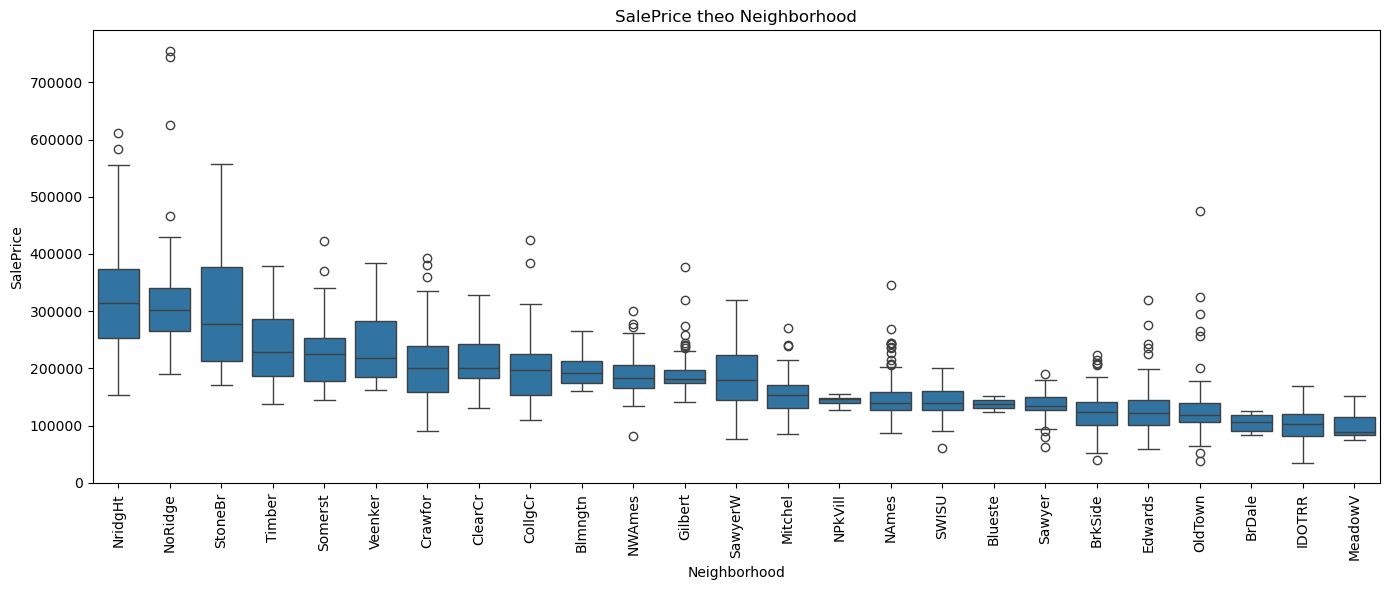

In [173]:
order = train.groupby("Neighborhood")[TARGET].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=train, x="Neighborhood", y=TARGET, order=order)
plt.xticks(rotation=90)
plt.title(f"{TARGET} theo Neighborhood")
plt.tight_layout()
plt.show()

In [174]:
print("\n--- Phân phối lớp: Biến Categorical (<= 10 lớp) ---")
for col in categorical_cols:
    if train[col].nunique(dropna=False) <= 10:
        print(f"\n[{col}] tỷ lệ phân phối:")
        # normalize=True trả về tỷ lệ phần trăm (0-1) thay vì số đếm
        print(train[col].value_counts(normalize=True, dropna=False).round(3))


--- Phân phối lớp: Biến Categorical (<= 10 lớp) ---

[MSZoning] tỷ lệ phân phối:
MSZoning
RL         0.788
RM         0.149
FV         0.045
RH         0.011
C (all)    0.007
Name: proportion, dtype: float64

[Street] tỷ lệ phân phối:
Street
Pave    0.996
Grvl    0.004
Name: proportion, dtype: float64

[Alley] tỷ lệ phân phối:
Alley
NaN     0.938
Grvl    0.034
Pave    0.028
Name: proportion, dtype: float64

[LotShape] tỷ lệ phân phối:
LotShape
Reg    0.634
IR1    0.332
IR2    0.028
IR3    0.007
Name: proportion, dtype: float64

[LandContour] tỷ lệ phân phối:
LandContour
Lvl    0.898
Bnk    0.043
HLS    0.034
Low    0.025
Name: proportion, dtype: float64

[Utilities] tỷ lệ phân phối:
Utilities
AllPub    0.999
NoSeWa    0.001
Name: proportion, dtype: float64

[LotConfig] tỷ lệ phân phối:
LotConfig
Inside     0.721
Corner     0.180
CulDSac    0.064
FR2        0.032
FR3        0.003
Name: proportion, dtype: float64

[LandSlope] tỷ lệ phân phối:
LandSlope
Gtl    0.947
Mod    0.045
Sev    0

### Thống kê giá trị thiếu và trùng

<Axes: >

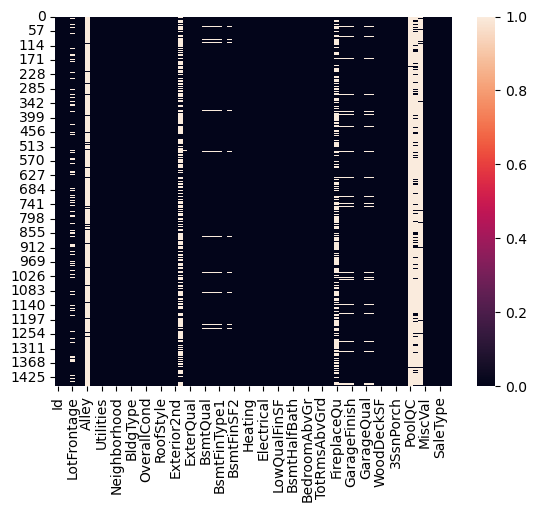

In [175]:
sns.heatmap(train.isnull())

In [176]:
missing_count = train.isnull().sum()
missing_percent = train.isnull().mean() * 100

missing_table = pd.DataFrame({
    "Missing": missing_count,
    "Percentage (%)": missing_percent
}).query("Missing > 0").sort_values(by="Missing", ascending=False)

print(f"Số lượng cột có dữ liệu thiếu: {len(missing_table)}")
display(missing_table)

Số lượng cột có dữ liệu thiếu: 19


,Missing,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [177]:
duplicate_rows = train.drop(columns=["Id"]).duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn (bỏ qua cột Id): {duplicate_rows}")

duplicate_ids = train["Id"].duplicated().sum()
print(f"Số lượng Id trùng lặp: {duplicate_ids}")

Số dòng trùng lặp hoàn toàn (bỏ qua cột Id): 0
Số lượng Id trùng lặp: 0


### Ma trận tương quan và Đa cộng tuyến

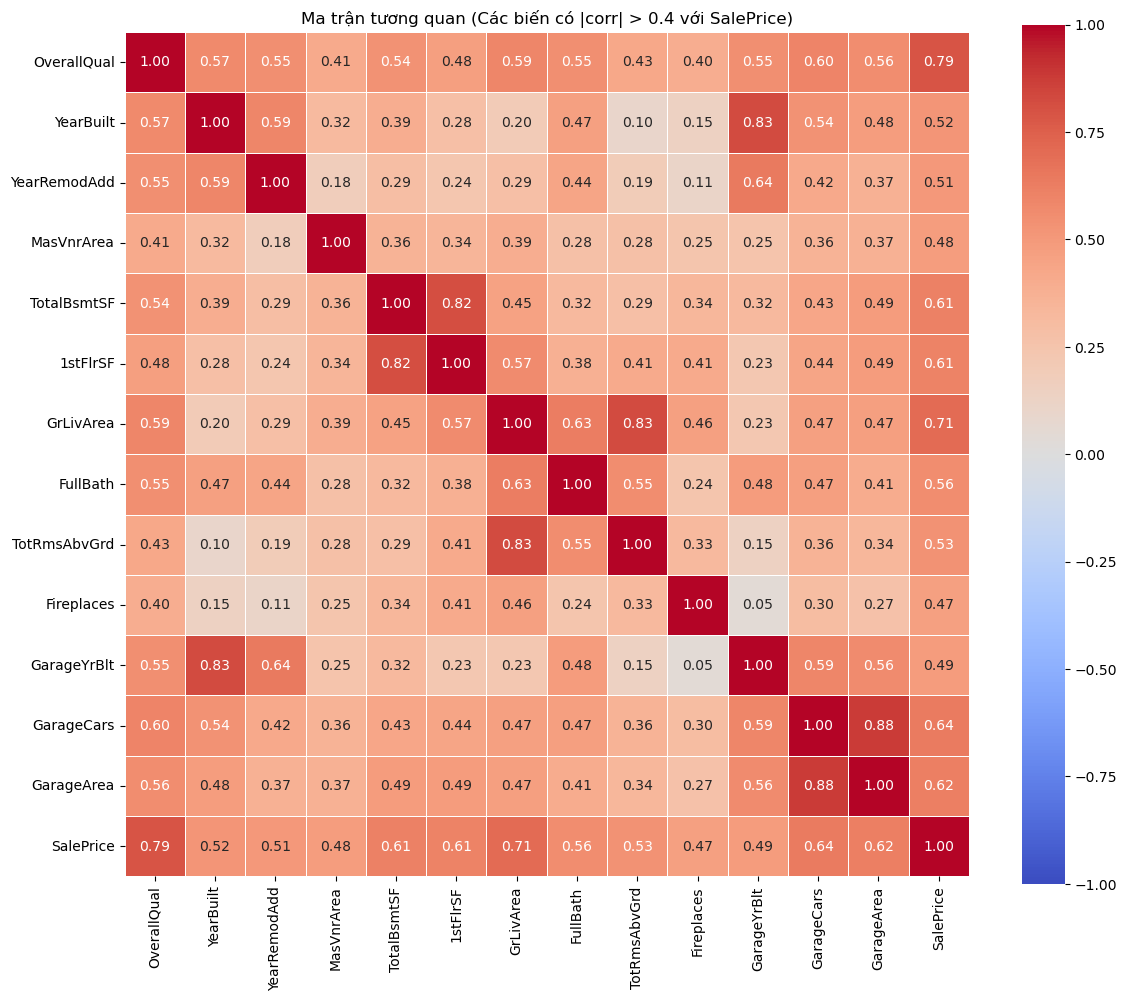

In [178]:
corr_with_target = train[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET)
top_features = corr_with_target[corr_with_target.abs() > 0.4].index.tolist()

if top_features:
    heatmap_data = train[top_features + [TARGET]].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5
    )
    plt.title(f"Ma trận tương quan (Các biến có |corr| > 0.4 với {TARGET})")
    plt.tight_layout()
    plt.show()
else:
    print(f"Không có biến nào đạt ngưỡng tương quan > 0.4 với {TARGET}.")

In [179]:
correlation = train[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("--- 10 biến có tương quan dương cao nhất ---")
print(correlation.head(10))
print("\n--- 10 biến có tương quan âm thấp nhất ---")
print(correlation.tail(10))

--- 10 biến có tương quan dương cao nhất ---
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

--- 10 biến có tương quan âm thấp nhất ---
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [180]:
print("\n--- Các cặp Feature có tương quan cao (|corr| >= 0.8) ---")
corr_matrix = train[numeric_cols].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) >= 0.80:
            high_corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": corr_value
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df["Abs Correlation"] = high_corr_df["Correlation"].abs()
    display(high_corr_df.sort_values(by="Abs Correlation", ascending=False))
else:
    print("Không có cặp biến nào có |correlation| >= 0.80")


--- Các cặp Feature có tương quan cao (|corr| >= 0.8) ---


,Feature 1,Feature 2,Correlation,Abs Correlation
3,GarageCars,GarageArea,0.882475,0.882475
0,YearBuilt,GarageYrBlt,0.825667,0.825667
2,GrLivArea,TotRmsAbvGrd,0.825489,0.825489
1,TotalBsmtSF,1stFlrSF,0.819530,0.819530


### Kiểm tra outlier

In [181]:
outlier_results = []

for col in numeric_cols:

    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (train[col] < lower_bound) |
        (train[col] > upper_bound)
    ).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outlier_count
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table = outlier_table.sort_values(
    by="Outliers",
    ascending=False
)

print(outlier_table)

          Feature       Q1        Q3  Lower Bound  Upper Bound  Outliers
28  EnclosedPorch     0.00      0.00        0.000        0.000       208
8      BsmtFinSF2     0.00      0.00        0.000        0.000       167
3     OverallCond     5.00      6.00        3.500        7.500       125
30    ScreenPorch     0.00      0.00        0.000        0.000       116
6      MasVnrArea     0.00    166.00     -249.000      415.000        96
0     LotFrontage    59.00     80.00       27.500      111.500        88
16   BsmtHalfBath     0.00      0.00        0.000        0.000        82
27    OpenPorchSF     0.00     68.00     -102.000      170.000        77
1         LotArea  7553.50  11601.50     1481.500    17673.500        69
20   KitchenAbvGr     1.00      1.00        1.000        1.000        68
10    TotalBsmtSF   795.75   1298.25       42.000     2052.000        61
32        MiscVal     0.00      0.00        0.000        0.000        52
19   BedroomAbvGr     2.00      3.00        0.500  

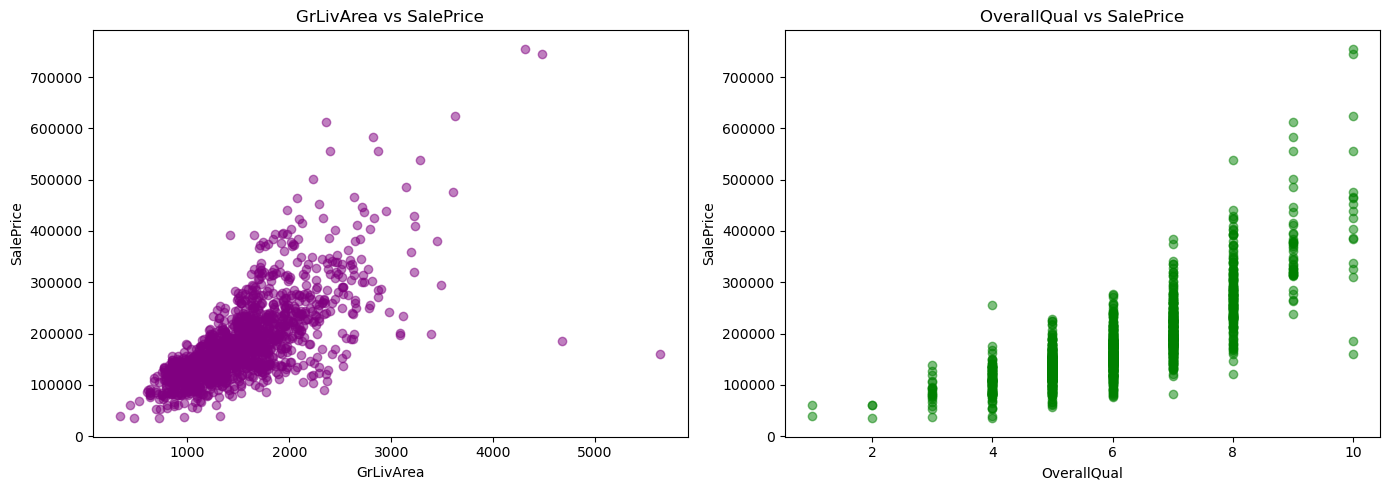

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train["GrLivArea"], train[TARGET], alpha=0.5, color="purple")
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel(TARGET)
axes[0].set_title("GrLivArea vs SalePrice")

axes[1].scatter(train["OverallQual"], train[TARGET], alpha=0.5, color="green")
axes[1].set_xlabel("OverallQual")
axes[1].set_ylabel(TARGET)
axes[1].set_title("OverallQual vs SalePrice")

plt.tight_layout()
plt.show()

### Phân phối SalePrice

In [183]:
print(f"Target: {TARGET}")

print("\nKiểu dữ liệu:")
print(train[TARGET].dtype)

print("\nThống kê SalePrice:")
print(train[TARGET].describe())

print("\nMedian:")
print(train[TARGET].median())

print("\nSkewness:")
print(train[TARGET].skew())

print("\nSố giá trị thiếu:")
print(train[TARGET].isna().sum())

print("\n5 giá trị SalePrice lớn nhất:")
print(train[TARGET].nlargest(5))

print("\n5 giá trị SalePrice nhỏ nhất:")
print(train[TARGET].nsmallest(5))

Target: SalePrice

Kiểu dữ liệu:
int64

Thống kê SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Median:
163000.0

Skewness:
1.8828757597682129

Số giá trị thiếu:
0

5 giá trị SalePrice lớn nhất:
691     755000
1182    745000
1169    625000
898     611657
803     582933
Name: SalePrice, dtype: int64

5 giá trị SalePrice nhỏ nhất:
495    34900
916    35311
968    37900
533    39300
30     40000
Name: SalePrice, dtype: int64


Skewness ban đầu : 1.883
Skewness sau log : 0.121


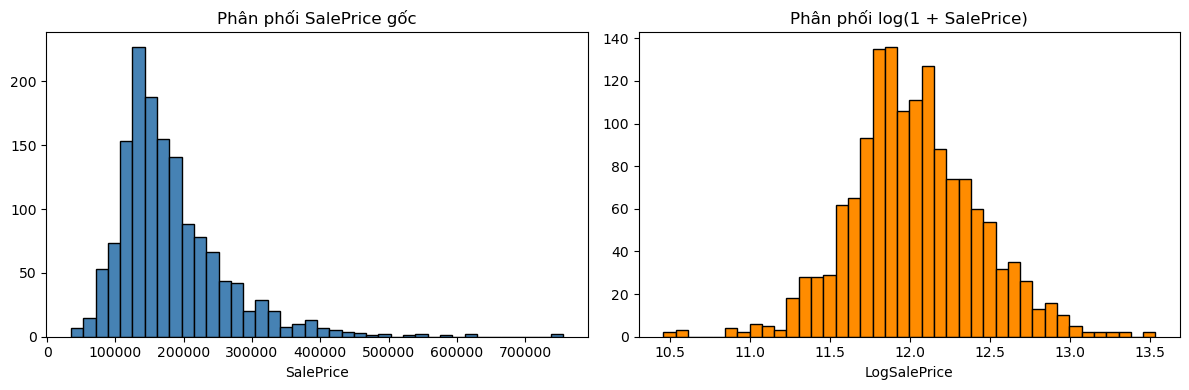

In [184]:
train["LogSalePrice"] = np.log1p(train[TARGET])

print(f"Skewness ban đầu : {train[TARGET].skew():.3f}")
print(f"Skewness sau log : {train['LogSalePrice'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train[TARGET], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("Phân phối SalePrice gốc")
axes[0].set_xlabel("SalePrice")

axes[1].hist(train["LogSalePrice"], bins=40, color="darkorange", edgecolor="black")
axes[1].set_title("Phân phối log(1 + SalePrice)")
axes[1].set_xlabel("LogSalePrice")

plt.tight_layout()
plt.show()

train.drop(columns=["LogSalePrice"], inplace=True)

In [185]:
print("\n" + "=" * 60)
print("TỔNG KẾT ANALYZE DATA")
print("=" * 60)

print(f"Số quan sát train       : {len(train)}")
print(f"Số quan sát test        : {len(test)}")
print(f"Số biến train ban đầu   : {train.shape[1] - 1}")
print(f"Target                  : {TARGET}")
print(f"Numerical features      : {len(numeric_cols)}")
print(f"Categorical features    : {len(categorical_cols)}")
print(f"Features có missing     : {len(missing_table)}")


TỔNG KẾT ANALYZE DATA
Số quan sát train       : 1460
Số quan sát test        : 1459
Số biến train ban đầu   : 80
Target                  : SalePrice
Numerical features      : 35
Categorical features    : 44
Features có missing     : 19


##  Khởi tạo và đọc dữ liệu

In [186]:
missing_percent = (train.isnull().sum() / len(train)) * 100

high_missing_cols = missing_percent[missing_percent > 70]
print("Các cột bị thiếu trên 70% dữ liệu:")
print(high_missing_cols)

Các cột bị thiếu trên 70% dữ liệu:
Alley          93.767123
PoolQC         99.520548
Fence          80.753425
MiscFeature    96.301370
dtype: float64


In [187]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

train_step1 = train.drop(columns=to_drop)
test_step1 = test.drop(columns=to_drop)

print(f'Kích thước Train sau khi làm sạch: {train_step1.shape}')
print(f'Kích thước Test sau khi làm sạch:  {test_step1.shape}')

print(
    'Các cột còn lại trong Train:',
    [c for c in to_drop if c in train_step1.columns],
)

Kích thước Train sau khi làm sạch: (1460, 76)
Kích thước Test sau khi làm sạch:  (1459, 75)
Các cột còn lại trong Train: []


In [188]:
def export_submission(
    test_ids, predictions_log, output_filename='submission.csv'
):

  final_prices = np.expm1(predictions_log)
  sub_df = pd.DataFrame({'Id': test_ids, 'SalePrice': final_prices.flatten()})
  sub_df.to_csv(output_filename, index=False)
  print(f'Đã xuất thành công file submission tại: {output_filename}')
  print(f'Số lượng bản ghi: {len(sub_df)}')
  return sub_df

test_ids = test['Id'].values
print('Đã lưu lại chuỗi ID tập Test để nộp bài')

Đã lưu lại chuỗi ID tập Test để nộp bài


## Khai phá dữ liệu (EDA)

###  Phân tích biến mục tiêu SalePrice

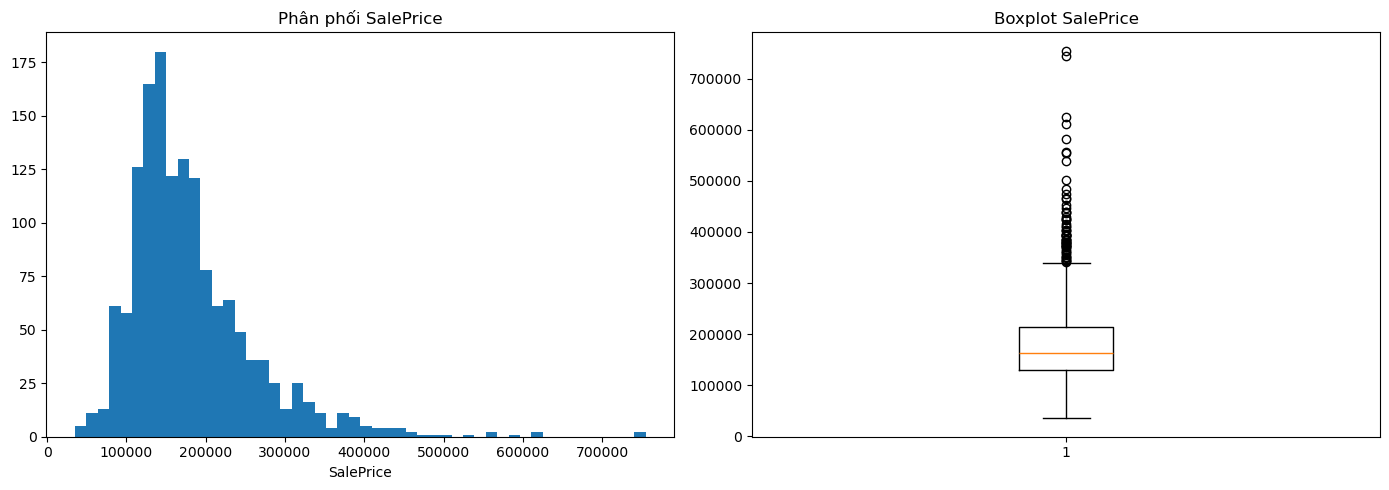

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train['SalePrice'], bins=50)
axes[0].set_title('Phân phối SalePrice')
axes[0].set_xlabel('SalePrice')
axes[1].boxplot(train['SalePrice'])
axes[1].set_title('Boxplot SalePrice')
plt.tight_layout()
plt.show()

Skewness trước log: 1.8828757597682129
Skewness sau log  : 0.12134661989685333


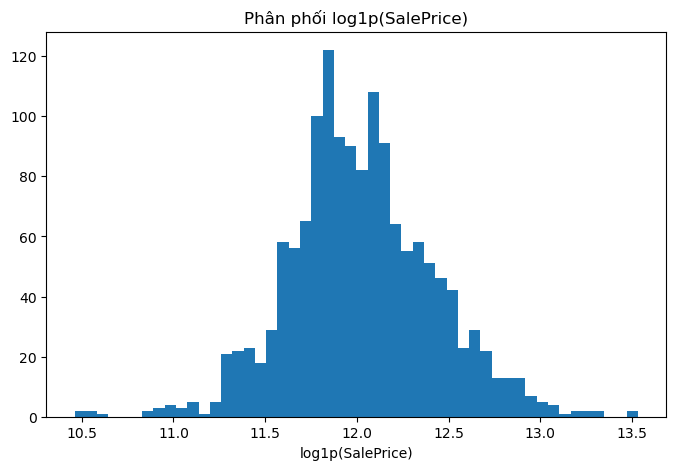

In [190]:
log_saleprice = np.log1p(train['SalePrice'])
print('Skewness trước log:', train['SalePrice'].skew())
print('Skewness sau log  :', log_saleprice.skew())

plt.figure(figsize=(8, 5))
plt.hist(log_saleprice, bins=50)
plt.title('Phân phối log1p(SalePrice)')
plt.xlabel('log1p(SalePrice)')
plt.show()

### Phân tích Missing Values

In [191]:
missing_table = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': train.isnull().mean() * 100
})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_table)

              Missing Count  Missing %
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


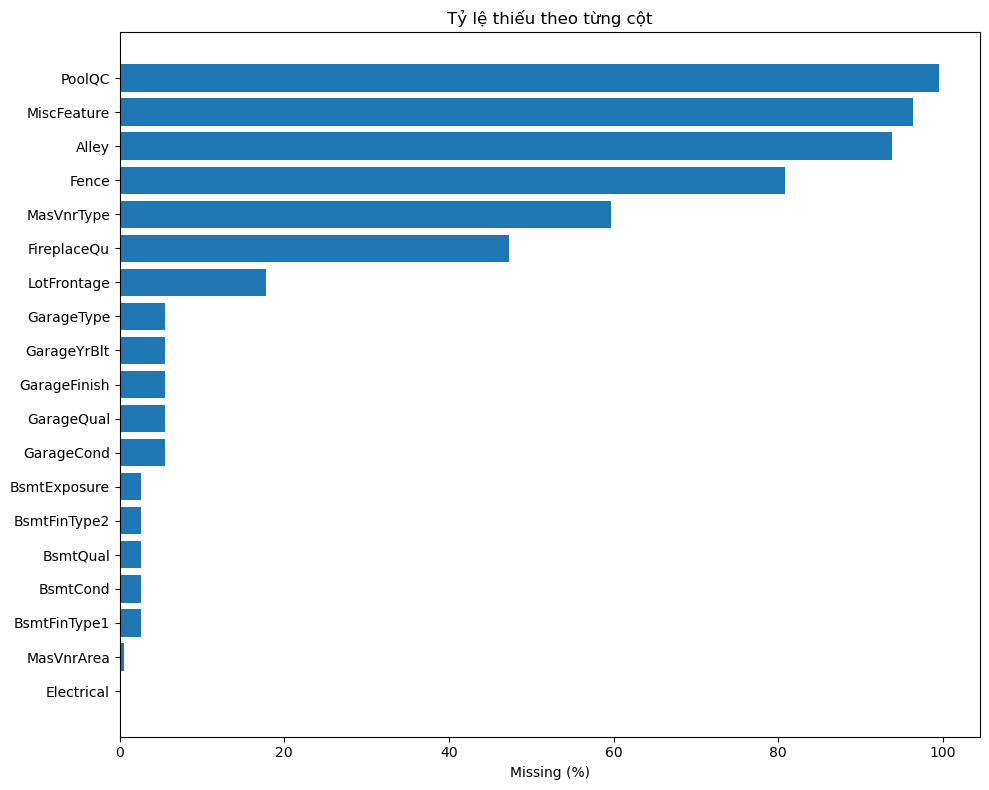

In [192]:
plt.figure(figsize=(10, 8))
plt.barh(missing_table.index, missing_table['Missing %'])
plt.xlabel('Missing (%)')
plt.title('Tỷ lệ thiếu theo từng cột')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Tương quan với SalePrice

In [193]:
numeric_cols_eda = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr = train[numeric_cols_eda].corr()
saleprice_corr = corr['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

top_corr = saleprice_corr.head(15)
print(top_corr)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


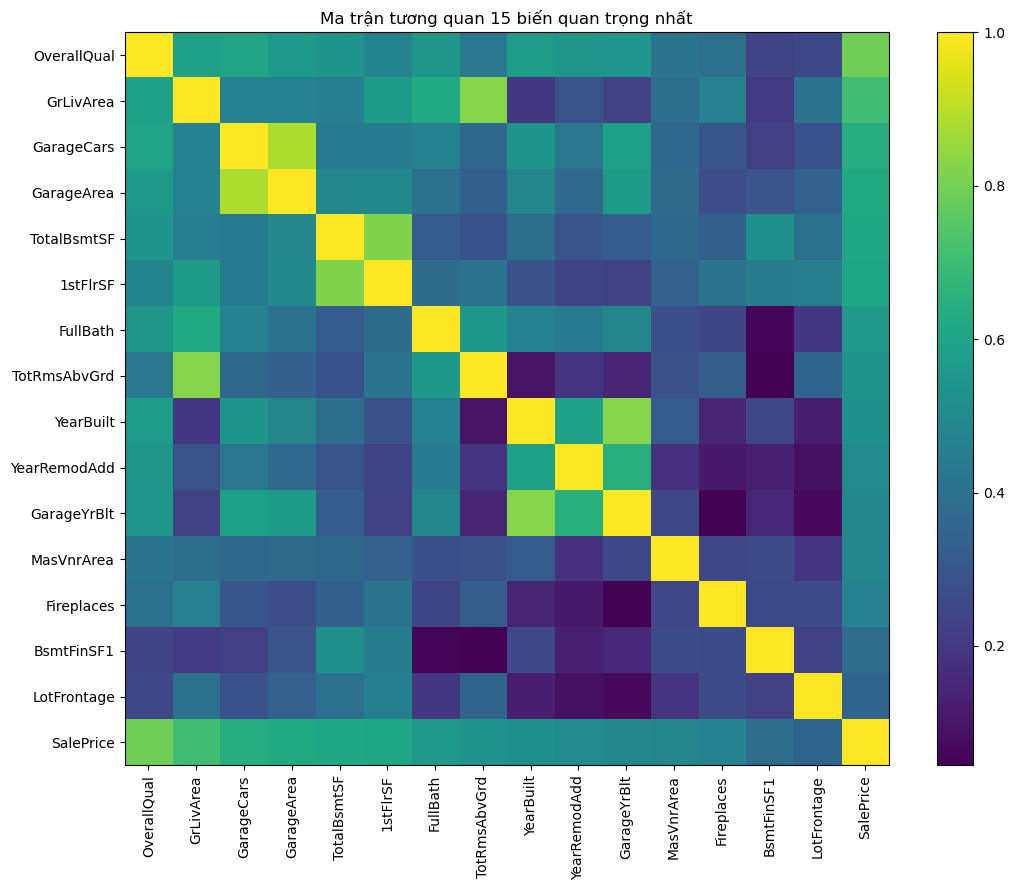

In [194]:
top_features = top_corr.index.tolist() + ['SalePrice']
plt.figure(figsize=(11, 9))
plt.imshow(train[top_features].corr(), aspect='auto')
plt.colorbar()
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title('Ma trận tương quan 15 biến quan trọng nhất')
plt.tight_layout()
plt.show()

### Quan hệ các biến quan trọng với SalePrice

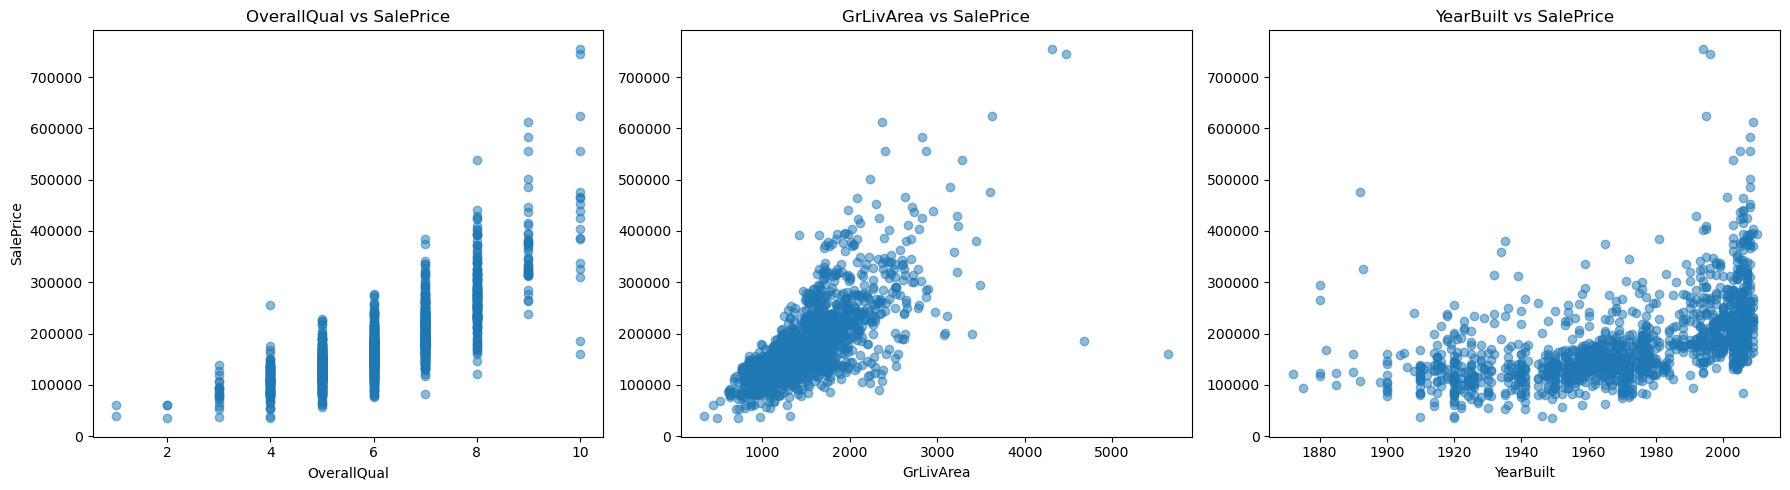

In [195]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(train['OverallQual'], train['SalePrice'], alpha=0.5)
axes[0].set_xlabel('OverallQual'); axes[0].set_ylabel('SalePrice')
axes[0].set_title('OverallQual vs SalePrice')
axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5)
axes[1].set_xlabel('GrLivArea')
axes[1].set_title('GrLivArea vs SalePrice')
axes[2].scatter(train['YearBuilt'], train['SalePrice'], alpha=0.5)
axes[2].set_xlabel('YearBuilt')
axes[2].set_title('YearBuilt vs SalePrice')
plt.tight_layout()
plt.show()

### EDA biến Categorical – Neighborhood

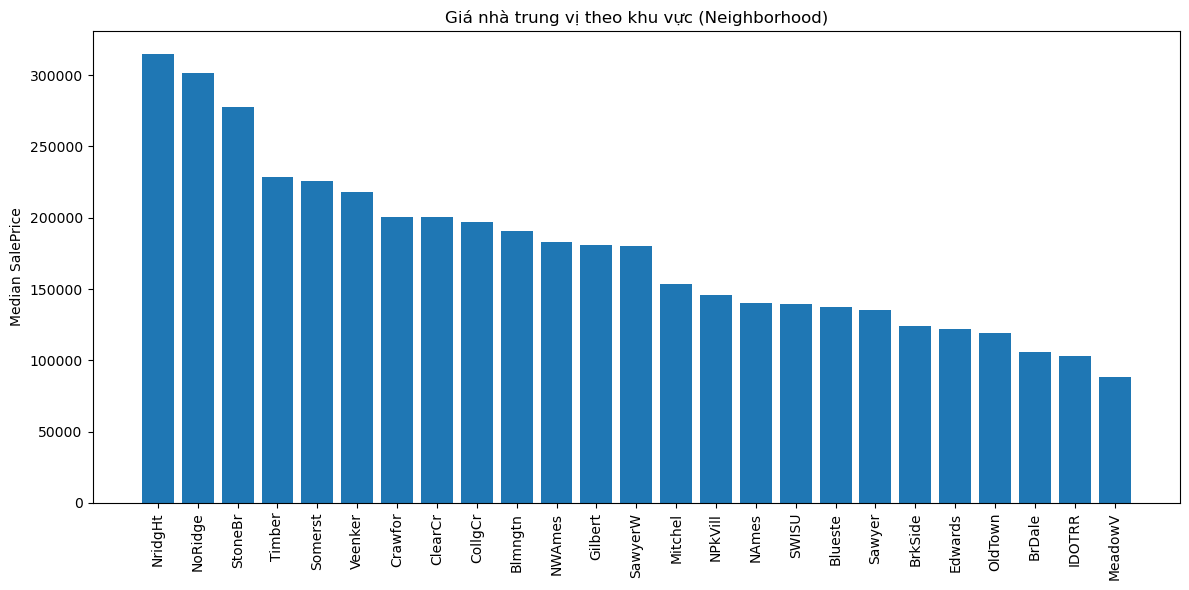

In [196]:
neighborhood_price = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(neighborhood_price.index, neighborhood_price.values)
plt.xticks(rotation=90)
plt.ylabel('Median SalePrice')
plt.title('Giá nhà trung vị theo khu vực (Neighborhood)')
plt.tight_layout()
plt.show()

### Kiểm tra Outlier

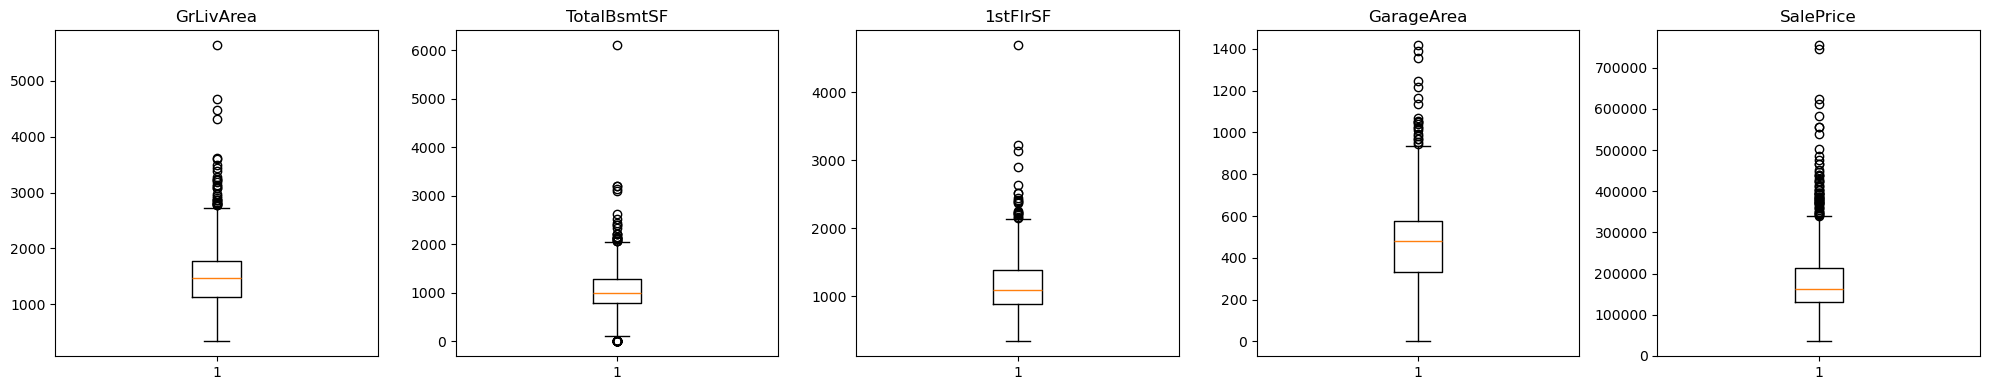

In [197]:
outlier_cols = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'SalePrice']
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(20, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(train[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Tiền xử lý dữ liệu

### Lọc Outlier & biến đổi Target

In [198]:
train_clean = train_step1[train_step1['GrLivArea'] <= 4000].copy()
test_clean = test_step1.copy()

print(f"Số lượng dòng tập Train sau khi xóa outlier: {train_clean.shape[0]}")

y_train_log = np.log1p(train_clean['SalePrice'])
train_clean = train_clean.drop(columns=['SalePrice'])

Số lượng dòng tập Train sau khi xóa outlier: 1456


### Xử lý Missing và Feature Engineering

In [199]:
ntrain = train_clean.shape[0]
all_data = pd.concat([train_clean, test_clean], axis=0).reset_index(drop=True)

none_cols = [
    'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2',
    'BsmtQual', 'BsmtCond', 'BsmtFinType1'
]
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(0)
all_data['MasVnrArea'] = all_data['MasVnrArea'].fillna(0)

nb_medians = all_data.iloc[:ntrain].groupby('Neighborhood')['LotFrontage'].median()
overall_median = all_data.loc[:ntrain - 1, 'LotFrontage'].median()

all_data['LotFrontage'] = all_data['LotFrontage'].fillna(
    all_data['Neighborhood'].map(nb_medians)
).fillna(overall_median)

numeric_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    train_median = all_data.loc[:ntrain - 1, col].median()
    all_data[col] = all_data[col].fillna(train_median)

if 'Electrical' in all_data.columns:
    train_mode = all_data.loc[:ntrain - 1, 'Electrical'].mode()[0]
    all_data['Electrical'] = all_data['Electrical'].fillna(train_mode)

categorical_cols = all_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    all_data[col] = all_data[col].fillna('None')

print(f"Tổng số giá trị NaN sau khi xử lý missing: {all_data.isnull().sum().sum()}")

Tổng số giá trị NaN sau khi xử lý missing: 0


In [200]:
all_data['TotSF'] = all_data['TotalBsmtSF'] + all_data['GrLivArea']
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

print("Kiểm tra 5 dòng đầu của các đặc trưng mới:")
display(all_data[['TotalBsmtSF', 'GrLivArea', 'TotSF', 'YearBuilt', 'YrSold', 'HouseAge']].head())

Kiểm tra 5 dòng đầu của các đặc trưng mới:


,TotalBsmtSF,GrLivArea,TotSF,YearBuilt,YrSold,HouseAge
0,856.0,1710,2566.0,2003,2008,5
1,1262.0,1262,2524.0,1976,2007,31
2,920.0,1786,2706.0,2001,2008,7
3,756.0,1717,2473.0,1915,2006,91
4,1145.0,2198,3343.0,2000,2008,8


### Mã hóa dữ liệu (Encoding)

In [201]:
qual_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in ordinal_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(qual_mapping).fillna(0).astype(int)

remaining_cat_cols = all_data.select_dtypes(include=['object']).columns
all_data = pd.get_dummies(all_data, columns=remaining_cat_cols, drop_first=True)

zero_std_cols = all_data.iloc[:ntrain].columns[
    np.isclose(all_data.iloc[:ntrain].std(numeric_only=True), 0)
]
print('Số cột std ≈ 0 bị loại:', len(zero_std_cols))
all_data = all_data.drop(columns=zero_std_cols)

Số cột std ≈ 0 bị loại: 7


### Chia dữ liệu và chuẩn hóa (Scaling)

In [202]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_full = all_data.iloc[:ntrain, :].copy()
X_test_final = all_data.iloc[ntrain:, :].copy()

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_log, test_size=0.176, random_state=42)

cols_to_scale = [c for c in X_train.columns if c != 'Neighborhood']

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test_final[cols_to_scale] = scaler.transform(X_test_final[cols_to_scale])

print("Đã hoàn tất chuẩn bị dữ liệu. Dữ liệu sẵn sàng cho MLP.")

Đã hoàn tất chuẩn bị dữ liệu. Dữ liệu sẵn sàng cho MLP.


## Xây dựng mô hình MLP

### Cài đặt và đăng nhập Wandb

### HUẤN LUYỆN & LOG 3 MÔ HÌNH BASELINE

In [203]:
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow.keras.backend as K

val_rmse_results = {}

dt_config = {
    "model_type": "DecisionTreeRegressor",
    "max_depth": 10,
    "min_samples_leaf": 4,
    "random_state": 42
}

run_dt = wandb.init(project=WANDB_PROJECT, name="baseline-decision-tree", config=dt_config, reinit=True)

dt_reg = DecisionTreeRegressor(
    max_depth=dt_config["max_depth"], 
    min_samples_leaf=dt_config["min_samples_leaf"], 
    random_state=dt_config["random_state"]
)
dt_reg.fit(X_train, y_train)

val_preds_dt = dt_reg.predict(X_val)
rmse_dt = np.sqrt(mean_squared_error(y_val, val_preds_dt))
val_rmse_results['Decision Tree'] = rmse_dt

wandb.log({"val_rmse": rmse_dt})
run_dt.finish()
print(f"[Baseline 1] Decision Tree - Val RMSE: {rmse_dt:.5f}")


xgb_config = {
    "model_type": "XGBRegressor",
    "n_estimators": 900,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

run_xgb = wandb.init(project=WANDB_PROJECT, name="baseline-xgboost", config=xgb_config, reinit=True)

xgb_reg = xgb.XGBRegressor(**xgb_config, booster='gbtree', n_jobs=-1)
xgb_reg.fit(X_train, y_train)

val_preds_xgb = xgb_reg.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, val_preds_xgb))
val_rmse_results['XGBoost'] = rmse_xgb

wandb.log({"val_rmse": rmse_xgb})
run_xgb.finish()
print(f"[Baseline 2] XGBoost - Val RMSE: {rmse_xgb:.5f}")


def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

keras_config = {
    "model_type": "Keras_ANN",
    "input_dim": X_train.shape[1],
    "layers": [50, 25, 50, 1],
    "activation": "relu",
    "optimizer": "adam",
    "batch_size": 32,
    "epochs": 300,
    "patience": 25
}

run_keras = wandb.init(project=WANDB_PROJECT, name="baseline-keras-ann", config=keras_config, reinit=True)

keras_ann = Sequential([
    Dense(50, kernel_initializer='he_uniform', activation='relu', input_dim=keras_config["input_dim"]),
    Dense(25, kernel_initializer='he_uniform', activation='relu'),
    Dense(50, kernel_initializer='he_uniform', activation='relu'),
    Dense(1, kernel_initializer='he_uniform')
])

keras_ann.compile(optimizer=keras_config["optimizer"], loss=root_mean_squared_error)
early_stop_keras = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=keras_config["patience"], restore_best_weights=True)

history_keras = keras_ann.fit(
    X_train.values, y_train.values,
    validation_data=(X_val.values, y_val.values),
    batch_size=keras_config["batch_size"],
    epochs=keras_config["epochs"],
    callbacks=[early_stop_keras],
    verbose=0
)

val_preds_keras = keras_ann.predict(X_val.values).flatten()
rmse_keras = np.sqrt(mean_squared_error(y_val, val_preds_keras))
val_rmse_results['Keras ANN'] = rmse_keras

wandb.log({
    "val_rmse": rmse_keras,
    "best_epoch": len(history_keras.history['loss']) - keras_config["patience"]
})
run_keras.finish()
print(f"[Baseline 3] Keras ANN - Val RMSE: {rmse_keras:.5f}")

val_rmse,▁
val_rmse,0.20118


[Baseline 1] Decision Tree - Val RMSE: 0.20118


val_rmse,▁
val_rmse,0.12562


[Baseline 2] XGBoost - Val RMSE: 0.12562


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


best_epoch,▁
val_rmse,▁
best_epoch,154
val_rmse,0.84659


[Baseline 3] Keras ANN - Val RMSE: 0.84659


# Chuẩn bị PYTORCH & Kiến trúc mạng ADVANCED MLP

In [204]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_final.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

class AdvancedMLP(nn.Module):
    def __init__(self, in_features, dropout_p=0.2):
        super(AdvancedMLP, self).__init__()
        self.network = nn.Sequential(
            # Block 1: Input -> 256
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            
            # Block 2: 256 -> 128
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            
            # Block 3: 128 -> 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x)

## Huấn luyện PYTORCH MLP với tracking thời gian thực qua Wandb

In [205]:
mlp_config = {
    "model_type": "PyTorch_Deep_MLP",
    "architecture": "in -> 256 -> 128 -> 64 -> 1",
    "in_features": X_train.shape[1],
    "batch_size": 32,
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "dropout_p": 0.2,
    "epochs": 250,
    "patience": 20
}

run_pytorch = wandb.init(
    project=WANDB_PROJECT,
    name="pytorch-advanced-mlp",
    config=mlp_config,
    reinit=True
)

train_loader = DataLoader(train_dataset, batch_size=mlp_config["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=mlp_config["batch_size"], shuffle=False)

model_mlp = AdvancedMLP(in_features=mlp_config["in_features"], dropout_p=mlp_config["dropout_p"]).to(device)

wandb.watch(model_mlp, log="all", log_freq=10)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=mlp_config["learning_rate"], weight_decay=mlp_config["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0

print("Đang huấn luyện PyTorch MLP và đồng bộ thời gian thực lên Dashboard W&B...")

for epoch in range(1, mlp_config["epochs"] + 1):

    model_mlp.train()
    running_train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        preds = model_mlp(X_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * X_b.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_rmse = np.sqrt(epoch_train_loss)
    
    model_mlp.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds = model_mlp(X_b)
            loss = criterion(preds, y_b)
            running_val_loss += loss.item() * X_b.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_rmse = np.sqrt(epoch_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)

    
    wandb.log({
        "epoch": epoch,
        "train_loss (MSE)": epoch_train_loss,
        "train_rmse": epoch_train_rmse,
        "val_loss (MSE)": epoch_val_loss,
        "val_rmse": epoch_val_rmse,
        "learning_rate": current_lr
    })
    

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model_mlp.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= mlp_config["patience"]:
            print(f"--> Kích hoạt Early Stopping tại Epoch {epoch}.")
            break

model_mlp.load_state_dict(best_model_weights)
best_rmse_pytorch = np.sqrt(best_val_loss)
val_rmse_results['PyTorch MLP'] = best_rmse_pytorch

torch.save(best_model_weights, "best_pytorch_mlp.pth")
model_artifact = wandb.Artifact("best-pytorch-mlp-weights", type="model")
model_artifact.add_file("best_pytorch_mlp.pth")
run_pytorch.log_artifact(model_artifact)

wandb.summary["best_val_rmse"] = best_rmse_pytorch
run_pytorch.finish()
print(f"[Nhiệm vụ 5] PyTorch MLP - Best Val RMSE: {best_rmse_pytorch:.5f}")

Đang huấn luyện PyTorch MLP và đồng bộ thời gian thực lên Dashboard W&B...
--> Kích hoạt Early Stopping tại Epoch 46.


wandb: WARNING Artifact "best-pytorch-mlp-weights" already exists with the same content. No new version will be created.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
learning_rate,█████████████████████████████████▁▁▁▁▁▁▁
train_loss (MSE),█▇▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_rmse,█▇▆▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss (MSE),█▇▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_rmse,█▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_rmse,0.38834
epoch,46
learning_rate,0.0005
train_loss (MSE),1.18723
train_rmse,1.0896


[Nhiệm vụ 5] PyTorch MLP - Best Val RMSE: 0.38834


## Đánh giá và so sánh biểu đồ trên WANDB

In [206]:
eval_run = wandb.init(project=WANDB_PROJECT, name="evaluation-model-comparison", reinit=True)

eval_df = pd.DataFrame({
    'Model': list(val_rmse_results.keys()),
    'Validation RMSE (log)': list(val_rmse_results.values())
}).sort_values(by='Validation RMSE (log)', ascending=True).reset_index(drop=True)

print("\n" + "="*45)
print("     BẢNG SO SÁNH HIỆU NĂNG 4 MÔ HÌNH")
print("="*45)
print(eval_df.to_string(index=False))
print("="*45)

wandb_table = wandb.Table(dataframe=eval_df)
wandb.log({"Evaluation_Comparison_Table": wandb_table})

bars = ax.barh(eval_df['Model'], eval_df['Validation RMSE (log)'], color=['#2ca02c', '#1f77b4', '#9467bd', '#d62728'])
ax.set_xlabel('Validation RMSE (log scale)', fontsize=11)
ax.set_title('So sánh độ lỗi Validation RMSE giữa 4 mô hình', fontsize=13)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.4f}", 
            va='center', ha='left', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(eval_df['Validation RMSE (log)']) * 1.2)
plt.tight_layout()

wandb.log({"Comparison_Bar_Chart": wandb.Image(fig)})
plt.show()

eval_run.finish()


     BẢNG SO SÁNH HIỆU NĂNG 4 MÔ HÌNH
        Model  Validation RMSE (log)
      XGBoost               0.125616
Decision Tree               0.201179
  PyTorch MLP               0.388338
    Keras ANN               0.846592


<Figure size 640x480 with 0 Axes>

## Dự đoán tập test & Xuất Submission

In [207]:
sub_run = wandb.init(project=WANDB_PROJECT, name="kaggle-submission-deployment", reinit=True)

model_mlp.eval()
with torch.no_grad():
    test_preds_tensor = model_mlp(X_test_tensor.to(device))
    test_preds_log = test_preds_tensor.cpu().numpy()

sub_filename = "submission_pytorch_mlp.csv"
sub_df = export_submission(
    test_ids=test_ids,
    predictions_log=test_preds_log,
    output_filename=sub_filename
)

sub_artifact = wandb.Artifact("kaggle-submission-csv", type="submission")
sub_artifact.add_file(sub_filename)
sub_run.log_artifact(sub_artifact)

sub_table = wandb.Table(dataframe=sub_df.head(10))
wandb.log({"Submission_Preview": sub_table})

sub_run.finish()
print("\n>>> Toàn bộ pipeline huấn luyện, so sánh và lưu trữ đã được đồng bộ 100% lên W&B!")

Đã xuất thành công file submission tại: submission_pytorch_mlp.csv
Số lượng bản ghi: 1459


wandb: WARNING Artifact "kaggle-submission-csv" already exists with the same content. No new version will be created.



>>> Toàn bộ pipeline huấn luyện, so sánh và lưu trữ đã được đồng bộ 100% lên W&B!


In [208]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_scores = np.sqrt(-cross_val_score(xgb_reg, X_train, y_train, scoring="neg_mean_squared_error", cv=kf))

dt_cv_scores = np.sqrt(-cross_val_score(dt_reg, X_train, y_train, scoring="neg_mean_squared_error", cv=kf))

print(f"5-Fold CV RMSE - Decision Tree: {dt_cv_scores.mean():.4f} (± {dt_cv_scores.std():.4f})")
print(f"5-Fold CV RMSE - XGBoost:       {xgb_cv_scores.mean():.4f} (± {xgb_cv_scores.std():.4f})")

5-Fold CV RMSE - Decision Tree: 0.1821 (± 0.0090)
5-Fold CV RMSE - XGBoost:       0.1186 (± 0.0082)


In [209]:
test_preds_xgb = xgb_reg.predict(X_test_final)
export_submission(test_ids, test_preds_xgb, output_filename='submission_best_xgboost.csv')

test_preds_blend = 0.85 * test_preds_xgb + 0.15 * test_preds_log.flatten()
export_submission(test_ids, test_preds_blend, output_filename='submission_ensemble.csv')

Đã xuất thành công file submission tại: submission_best_xgboost.csv
Số lượng bản ghi: 1459
Đã xuất thành công file submission tại: submission_ensemble.csv
Số lượng bản ghi: 1459


,Id,SalePrice
0,1461,129423.140625
1,1462,169781.984375
2,1463,185885.343750
3,1464,190479.078125
4,1465,189935.421875
...,...,...
1454,2915,83783.179688
1455,2916,75617.023438
1456,2917,154316.562500
1457,2918,95892.273438


### Dự đoán trên tập Test & Xuất Submission

In [210]:
best_model_name = eval_df.iloc[0]['Model']
print(f'Model tốt nhất theo Validation RMSE: {best_model_name}')

if best_model_name == 'PyTorch MLP':
    model_mlp.eval()
    with torch.no_grad():
        test_pred_log = model_mlp(X_test_tensor.to(device)).cpu().numpy().flatten()
elif best_model_name == 'XGBoost':
    test_pred_log = xgb_reg.predict(X_test_final)
elif best_model_name == 'Decision Tree':
    test_pred_log = dt_reg.predict(X_test_final)
else: 
    test_pred_log = keras_ann.predict(X_test_final.values).flatten()


print('Số NaN trong prediction:', np.isnan(test_pred_log).sum())
print('Số Inf trong prediction:', np.isinf(test_pred_log).sum())

submission_df = export_submission(test_ids, test_pred_log, output_filename='submission.csv')
submission_df.head()

Model tốt nhất theo Validation RMSE: XGBoost
Số NaN trong prediction: 0
Số Inf trong prediction: 0
Đã xuất thành công file submission tại: submission.csv
Số lượng bản ghi: 1459


,Id,SalePrice
0,1461,127608.132812
1,1462,161852.781250
2,1463,184276.484375
3,1464,193467.625000
4,1465,187348.265625
